In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import pvlib
from pvlib.pvsystem import PVSystem
from pvlib.location import Location
from pvlib.modelchain import ModelChain

We can actually get weather data from NASA POWER API through pvlib and also pvlib will automatically format it in a way that it prefers for doing things. 

In [5]:
weather_df, meta = pvlib.iotools.get_nasa_power(
    latitude=36.07, 
    longitude=-86.75, 
    start='2025-01-01', 
    end='2025-01-01', 
    parameters=['ghi', 'dni', 'dhi', 'temp_air', 'wind_speed']
)

The data is the following:

GHI - Global Horizontal Irradiance. This is the total light hitting the ground. 

DNI - Direct Normal Irradiance. This is the light coming from the sun directly. 

DHI - Diffuse Horizontal Irradiance. This is the scattered light from the clouds. 

Using these values, pvlib will do calculations for the sun position and take into account factors of the actual solar panel system itself to make a prediction for the theoretical yield of the solar panel. We just need to tell pvlib the location. I will just for fun use my hometown of Nashville but of course we would change this to correspond to whatever solar panel system we are looking at from the NREL data set.

In [7]:
location = Location(
    latitude=36.07, 
    longitude=-86.75, 
    tz='UTC', 
    name='Nashville_Project'
)

We also need to put in the parameters for the actual solar panel system being used. The surface_tilt and surface_azimuth parameters will need to be found for the particular system we are looking at. The 'sapm' and 'open_rack_glass_glass' is about the specific temperature model being used (SAPM) and open rack is for the panels being out in a field and glass-glass meaning both sides of the solar panel have glass which will affect solar panel temperature.

In [15]:
sandia_modules = pvlib.pvsystem.retrieve_sam('SandiaMod')
sapm_inverters = pvlib.pvsystem.retrieve_sam('cecinverter')

panel = sandia_modules['Canadian_Solar_CS5P_220M___2009_']
inverter = sapm_inverters['ABB__MICRO_0_25_I_OUTD_US_208__208V_']

temp_params = pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS['sapm']['open_rack_glass_glass']

system = PVSystem(
    surface_tilt=30, 
    surface_azimuth=180,
    module_parameters=panel,
    inverter_parameters=inverter,
    temperature_model_parameters=temp_params
)

Now we use the pvlib model object that builds a model for the solar panel system that will be used to calculate theoretical yields. The AOI model is for the angle of incidence so it calculates the actual angle of incidence between rays from the sun and the solar panel. Apparently spectral model has to do with if it takes into account the actual color of light but that apparently requires a lot more atmospheric data so leaving it out is apparently OK. There's also an SAPM AOI model which is apparently Sandia National Lab's (SNL's) data for specific solar panels. We can only use it if we happen to be using data with solar panels that SNL did testing with. Using physical AOI model will allow us to use that for all setups that we come across. 

In [10]:
mc = ModelChain(system, location, aoi_model='physical', spectral_model='no_loss')

We pass the weather Pandas dataframe to get a prediction.

In [16]:
mc.run_model(weather_df)

ModelChain: 
  name: None
  clearsky_model: ineichen
  transposition_model: haydavies
  solar_position_method: nrel_numpy
  airmass_model: kastenyoung1989
  dc_model: sapm
  ac_model: sandia_inverter
  aoi_model: physical_aoi_loss
  spectral_model: no_spectral_loss
  temperature_model: sapm_temp
  losses_model: no_extra_losses

In [17]:
predicted_power_watts = mc.results.ac

In [18]:
print(predicted_power_watts)

2025-01-01 00:00:00+00:00    -0.075000
2025-01-01 01:00:00+00:00    -0.075000
2025-01-01 02:00:00+00:00    -0.075000
2025-01-01 03:00:00+00:00    -0.075000
2025-01-01 04:00:00+00:00    -0.075000
2025-01-01 05:00:00+00:00    -0.075000
2025-01-01 06:00:00+00:00    -0.075000
2025-01-01 07:00:00+00:00    -0.075000
2025-01-01 08:00:00+00:00    -0.075000
2025-01-01 09:00:00+00:00    -0.075000
2025-01-01 10:00:00+00:00    -0.075000
2025-01-01 11:00:00+00:00    -0.075000
2025-01-01 12:00:00+00:00    -0.075000
2025-01-01 13:00:00+00:00    -0.075000
2025-01-01 14:00:00+00:00     8.989591
2025-01-01 15:00:00+00:00    14.268829
2025-01-01 16:00:00+00:00    19.830989
2025-01-01 17:00:00+00:00    22.954826
2025-01-01 18:00:00+00:00    14.234327
2025-01-01 19:00:00+00:00    39.791285
2025-01-01 20:00:00+00:00    47.414031
2025-01-01 21:00:00+00:00    44.881442
2025-01-01 22:00:00+00:00     6.668860
2025-01-01 23:00:00+00:00    -0.075000
dtype: float64


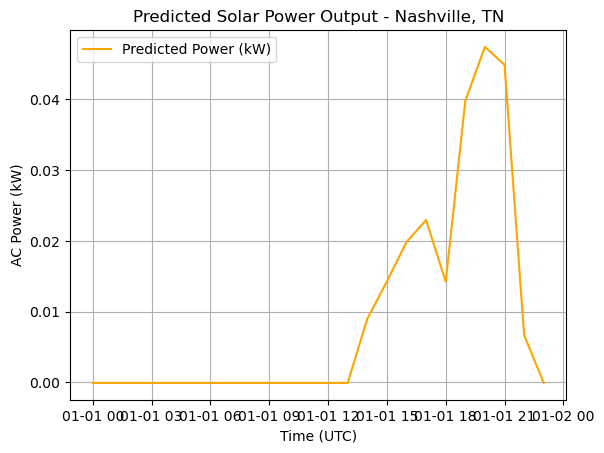

In [19]:
plt.plot(predicted_power_watts.index, predicted_power_watts / 1000, label='Predicted Power (kW)', color='orange')
plt.title('Predicted Solar Power Output - Nashville, TN')
plt.ylabel('AC Power (kW)')
plt.xlabel('Time (UTC)')

plt.grid()
plt.legend()